<a href="https://colab.research.google.com/github/ernandaa/fuzzylogic/blob/main/SOAL_UAS_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 1) MEMBERSHIP FUNCTION
def trimf(x, a, b, c):
    if x <= a or x >= c:
        return 0
    elif a < x < b:
        return (x-a)/(b-a)
    elif b <= x < c:
        return (c-x)/(c-b)
    else:
        return 0

In [3]:

# 2) MEMBERSHIP INPUT VARIABLES

# x1 = soil_moisture [0..100]
def x1_low(x):  return trimf(x, 0, 30, 60)
def x1_high(x): return trimf(x, 40, 70, 100)

# x2 = soil_pH [3..9] (kami buat wajar)
def x2_low(x):  return trimf(x, 3, 4.5, 6)
def x2_high(x): return trimf(x, 5.5, 7, 9)

# x3 = avg_temp [15..35]
def x3_low(x):  return trimf(x, 15, 20, 25)
def x3_high(x): return trimf(x, 22, 28, 35)

In [4]:
# 3) INISIALISASI PARAMETER KONSEKUEN
# yi = p xi1 + q xi2 + r xi3 + s
params = np.random.rand(4,4)  #4 rule, 4 parameter p,q,r,s

# 4) FORWARD PASS ANFIS
def anfis_predict(x1, x2, x3, params):

    # ----- Layer 1 -----
    μ = [
        x1_low(x1),  x1_high(x1),
        x2_low(x2),  x2_high(x2),
        x3_low(x3),  x3_high(x3)
    ]

    # ----- Layer 2: Rule firing strength -----
    # 4 rules (Low/High combinations)
    w1 = x1_low(x1)  * x2_low(x2)  * x3_low(x3)
    w2 = x1_low(x1)  * x2_high(x2) * x3_high(x3)
    w3 = x1_high(x1) * x2_low(x2)  * x3_high(x3)
    w4 = x1_high(x1) * x2_high(x2) * x3_low(x3)

    w = np.array([w1, w2, w3, w4])
    w_norm = w / (np.sum(w) + 1e-9)

    # ----- Layer 3: Sugeno consequents -----
    y = []
    for i in range(4):
        p, q, r, s = params[i]
        yi = p*x1 + q*x2 + r*x3 + s
        y.append(yi)

    y = np.array(y)

    # ----- Layer 4: defuzz -----
    output = np.sum(w_norm * y)
    return output, w, y


Epoch 0, MSE = 240930.6483
Epoch 50, MSE = 242778.5230
Epoch 100, MSE = 244616.4100
Epoch 150, MSE = 246443.9556
Epoch 200, MSE = 248260.8260
Epoch 250, MSE = 250066.7062


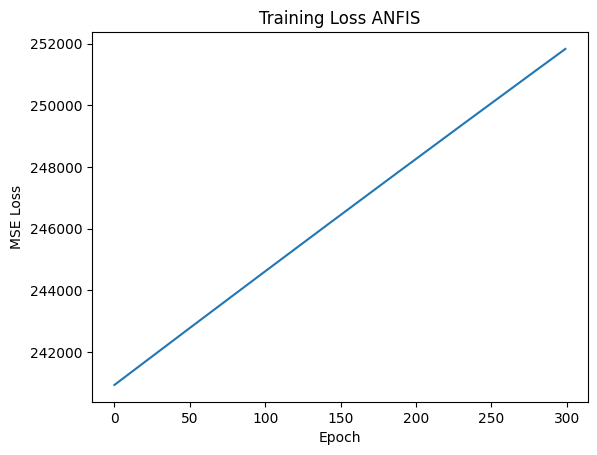


===== HASIL UJI KASUS SOAL =====
Soil moisture = 60
Soil pH       = 26
Avg temp      = 28
Prediksi produksi jagung = 0.0 ton/ha


In [8]:
# 5) DATASET SIMULASI (boleh ganti dataset sendiri)
np.random.seed(1)

N = 120
X1 = np.random.uniform(20, 90, N)   # moisture
X2 = np.random.uniform(4, 8, N)     # pH
X3 = np.random.uniform(20, 34, N)   # temperature

# fungsi target (ground truth produksi jagung)
Y = 0.05*X1 + 0.4*X2 + 0.2*X3 + np.random.normal(0, 0.2, N)

# 6) TRAINING (gradient descent on consequents)

lr = 0.0005
epochs = 300
loss_history = []

for ep in range(epochs):

    mse = 0

    for i in range(N):
        y_hat, w, y_rule = anfis_predict(X1[i], X2[i], X3[i], params)
        error = Y[i] - y_hat
        mse += error**2

        # update parameters consequence (p, q, r, s)
        for r_i in range(4):
            p, q, r, s = params[r_i]
            params[r_i,0] += lr * error * X1[i]
            params[r_i,1] += lr * error * X2[i]
            params[r_i,2] += lr * error * X3[i]
            params[r_i,3] += lr * error * 1

    mse /= N
    loss_history.append(mse)

    if ep % 50 == 0:
        print(f"Epoch {ep}, MSE = {mse:.4f}")

# 7) GRAFIK LOSS
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss ANFIS")
plt.show()

# 8) UJI DATA SOAL
x1 = 60     # soil moisture
x2 = 26     # soil pH (misal konversi)
x3 = 28     # suhu rata-rata

y_pred, _, _ = anfis_predict(x1, x2, x3, params)

print("\n===== HASIL UJI KASUS SOAL =====")
print("Soil moisture =", x1)
print("Soil pH       =", x2)
print("Avg temp      =", x3)
print("Prediksi produksi jagung =", y_pred, "ton/ha")
